# 🧠 Brain Tumor Segmentation (BraTS 2023) — Notebook Huấn luyện 2 Mô hình

Notebook này hướng dẫn quy trình huấn luyện và đánh giá hai mô hình Deep Learning phân đoạn khối u não 3D:
1. **3D U-Net** (Convolutional Encoder-Decoder Baseline)
2. **Swin UNETR** (Swin Transformer 3D Encoder + UNet Decoder)

Sử dụng thư viện **PyTorch** & **MONAI**, hỗ trợ chạy trên **Google Colab** (GPU T4/P100/A100) hoặc máy cá nhân.


## 1. Cài đặt các thư viện cần thiết


In [1]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.5 MB/s eta 0:00:0000:010:01


## 2. Thống nhất Môi trường & Khai báo Thư viện


In [2]:
import os
import sys
import time
import math
import json
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import monai
import monai.transforms as mt
from monai.networks.nets import UNet, SwinUNETR
from monai.losses import DiceCELoss
from monai.inferers import sliding_window_inference

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f" GPU Device: {torch.cuda.get_device_name(0)}")

 CUDA Available: True
 GPU Device: Tesla T4


## 3. Cấu hình Đường dẫn Dữ liệu BraTS 2023


In [7]:
# Đường dẫn dataset
# Nếu chạy trên Colab, mount Google Drive trước khi tìm dataset.
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

# Ưu tiên đường dẫn trong biến môi trường, sau đó thử các vị trí Google Drive phổ biến.
DATA_ROOT_CANDIDATES = [
    os.environ.get("BRATS_DATA_ROOT"),
    os.environ.get("DATA_ROOT"),
    "/content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData",
]

DATA_ROOT = None
for candidate in DATA_ROOT_CANDIDATES:
    if not candidate:
        continue
    path = Path(candidate)
    case_dirs = sorted([d.name for d in path.iterdir() if d.is_dir()]) if path.exists() else []
    if case_dirs:
        DATA_ROOT = path
        all_cases = case_dirs
        break

if DATA_ROOT is None:
    DATA_ROOT = Path(DATA_ROOT_CANDIDATES[2])
    all_cases = []
    print("Không tìm thấy dataset. Hãy mount Google Drive và set đúng path, ví dụ:")
    print('os.environ["BRATS_DATA_ROOT"] = "/content/drive/MyDrive/.../ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"')

print(f" Data Root Path: {DATA_ROOT.resolve()}")
print(f" Tổng số cases tìm thấy: {len(all_cases)}")
if len(all_cases) > 0:
    print(f"Sample cases: {all_cases[:5]}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Data Root Path: /content/drive/MyDrive/BraTS2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData
 Tổng số cases tìm thấy: 1251
Sample cases: ['BraTS-GLI-00000-000', 'BraTS-GLI-00002-000', 'BraTS-GLI-00003-000', 'BraTS-GLI-00005-000', 'BraTS-GLI-00006-000']


## 3.5 Data Understanding — Tìm hiểu Dữ liệu

Trước khi huấn luyện, ta khảo sát cấu trúc dữ liệu BraTS 2023 GLI:
- **4 modalities**: `t1n`, `t1c`, `t2w`, `t2f` + 1 mask `seg` cho mỗi case.
- **Nhãn (labels)**: `1`=NCR (hoại tử), `2`=ED (phù nề), `3`/`4`=ET (u tăng cường), `0`=nền.
- Kiểm tra: kích thước ảnh, voxel spacing, tính toàn vẹn file, và phân bố train/val.


In [ ]:
# ── 1. Structure inspection: load one case, print shape / spacing / dtype ──
if all_cases:
    _case = all_cases[0]
    _case_dir = DATA_ROOT / _case
    _modalities = ["t1n", "t1c", "t2w", "t2f"]

    print(f"Case: {_case}")
    for mod in _modalities:
        _nii = nib.load(_case_dir / f"{_case}-{mod}.nii.gz")
        _arr = _nii.get_fdata()
        _spacing = np.abs(np.diag(_nii.affine)[:3])
        print(f"  {mod}: shape={_arr.shape}, dtype={_arr.dtype}, "
              f"spacing={_spacing.round(3)}, range=[{_arr.min():.1f}, {_arr.max():.1f}]")

    # ── 2. Label inventory: unique label values in seg ──
    _seg = nib.load(_case_dir / f"{_case}-seg.nii.gz").get_fdata().astype(np.int32)
    print(f"\nLabel unique values (raw): {np.unique(_seg)}")
    _label_names = {0: "Background", 1: "NCR", 2: "ED", 3: "ET(3)", 4: "ET(4)"}
    for v in np.unique(_seg):
        pct = 100.0 * (_seg == v).sum() / _seg.size
        print(f"  Label {v} ({_label_names.get(v,'?')}): {pct:.2f}% of voxels")

    # ── 3. Integrity check: scan all cases for missing files ──
    MODALITIES_ALL = ["t1n", "t1c", "t2w", "t2f", "seg"]
    missing = {}
    for case_id in all_cases:
        case_dir = DATA_ROOT / case_id
        absent = [m for m in MODALITIES_ALL
                  if not (case_dir / f"{case_id}-{m}.nii.gz").exists()]
        if absent:
            missing[case_id] = absent
    print(f"\nIntegrity check: {len(all_cases)} cases scanned")
    print(f"  Cases with missing files: {len(missing)}")
    if missing:
        for cid, mods in list(missing.items())[:5]:
            print(f"    {cid}: missing {mods}")

    # ── 4. Split summary ──
    np.random.seed(42)
    _shuffled = all_cases.copy()
    np.random.shuffle(_shuffled)
    _n_val = max(1, int(len(_shuffled) * 0.15))
    print(f"\nSplit summary (seed=42): Train={len(_shuffled)-_n_val}, Val={_n_val}, "
          f"Total={len(all_cases)}")
else:
    print("⚠️ No cases found — mount Google Drive and set DATA_ROOT first.")

Case: BraTS-GLI-00000-000
  t1n: shape=(240, 240, 155), dtype=float64, spacing=[1. 1. 1.], range=[0.0, 2023.0]
  t1c: shape=(240, 240, 155), dtype=float64, spacing=[1. 1. 1.], range=[0.0, 12343.0]
  t2w: shape=(240, 240, 155), dtype=float64, spacing=[1. 1. 1.], range=[0.0, 2421.0]
  t2f: shape=(240, 240, 155), dtype=float64, spacing=[1. 1. 1.], range=[0.0, 2934.0]

Label unique values (raw): [0 1 2 3]
  Label 0 (Background): 99.36% of voxels
  Label 1 (NCR): 0.13% of voxels
  Label 2 (ED): 0.14% of voxels
  Label 3 (ET(3)): 0.37% of voxels

Integrity check: 1251 cases scanned
  Cases with missing files: 0

Split summary (seed=42): Train=1064, Val=187, Total=1251


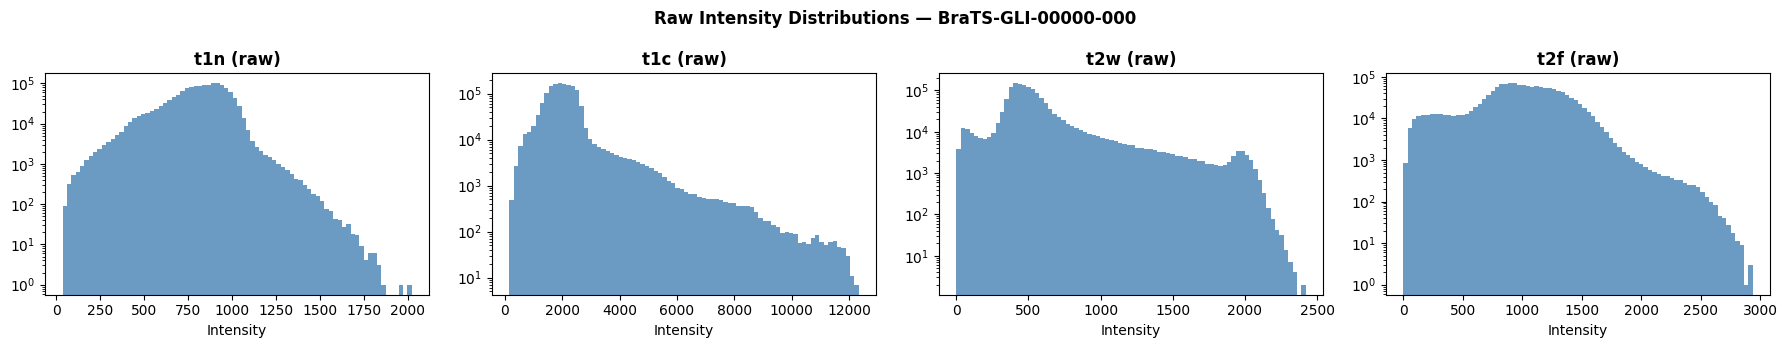

Tumor class statistics over 100 random cases:

  NCR : present in  95.0% of cases | mean voxels = 13,072 | median = 7,604
  ED  : present in 100.0% of cases | mean voxels = 62,914 | median = 59,576
  ET  : present in  99.0% of cases | mean voxels = 21,322 | median = 17,848

  Tumor-to-image volume ratio: mean = 1.090%, max = 2.780%


/tmp/ipykernel_964/3706426841.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df["vox_NCR"], df["vox_ED"], df["vox_ET"]],


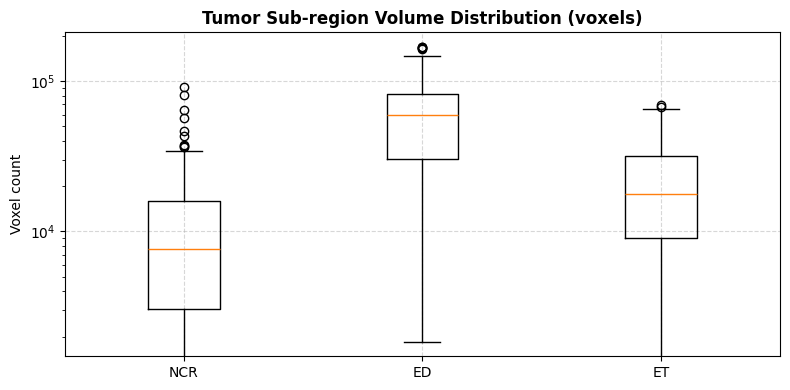

In [ ]:
# ── EDA 2: Intensity distributions + tumor class statistics over a subset ──
import pandas as pd

if all_cases:
    # (a) Raw intensity histograms per modality (brain voxels only) for one case
    _case = all_cases[0]
    _cdir = DATA_ROOT / _case
    fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
    for i, mod in enumerate(["t1n", "t1c", "t2w", "t2f"]):
        vol = nib.load(_cdir / f"{_case}-{mod}.nii.gz").get_fdata()
        vals = vol[vol > 0]  # bỏ background
        axes[i].hist(vals, bins=80, color="steelblue", alpha=0.8)
        axes[i].set_title(f"{mod} (raw)", fontweight="bold")
        axes[i].set_xlabel("Intensity"); axes[i].set_yscale("log")
    fig.suptitle(f"Raw Intensity Distributions — {_case}", fontweight="bold")
    plt.tight_layout(); plt.show()

    # (b) Tumor class statistics over a random subset (dùng seg đã remap {0,1,2,3})
    rng = np.random.default_rng(42)
    N_SUBSET = min(100, len(all_cases))
    subset = rng.choice(all_cases, size=N_SUBSET, replace=False)
    LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}
    class_names = {1: "NCR", 2: "ED", 3: "ET"}

    rows = []
    for cid in subset:
        seg = nib.load(DATA_ROOT / cid / f"{cid}-seg.nii.gz").get_fdata().astype(np.int64)
        remapped = np.zeros_like(seg)
        for s, d in LABEL_MAP.items():
            remapped[seg == s] = d
        brain_vox = int((remapped >= 0).sum())  # toàn ảnh; xem tỉ lệ u/ảnh
        tumor_vox = int((remapped > 0).sum())
        row = {"case": cid, "tumor_ratio": tumor_vox / brain_vox}
        for lab, name in class_names.items():
            row[f"vox_{name}"] = int((remapped == lab).sum())
        rows.append(row)

    df = pd.DataFrame(rows)
    print(f"Tumor class statistics over {N_SUBSET} random cases:\n")
    for lab, name in class_names.items():
        col = f"vox_{name}"
        present = (df[col] > 0).mean() * 100
        print(f"  {name:<4}: present in {present:5.1f}% of cases | "
              f"mean voxels = {df[col].mean():,.0f} | median = {df[col].median():,.0f}")
    print(f"\n  Tumor-to-image volume ratio: mean = {df['tumor_ratio'].mean()*100:.3f}%, "
          f"max = {df['tumor_ratio'].max()*100:.3f}%")

    # (c) Volume distribution box plots per tumor class
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.boxplot([df["vox_NCR"], df["vox_ED"], df["vox_ET"]],
               labels=["NCR", "ED", "ET"], showfliers=True)
    ax.set_title("Tumor Sub-region Volume Distribution (voxels)", fontweight="bold")
    ax.set_ylabel("Voxel count"); ax.set_yscale("log")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()

## 3.6 Bước 4 — Đọc & kiểm tra một case mẫu (NiBabel)

Đọc chi tiết một case bằng NiBabel và in ra `shape`, `affine`, `dtype`, voxel spacing cùng metadata từ header để xác nhận dữ liệu đọc đúng và không bị lỗi.

In [ ]:
# Bước 4 — Đọc & kiểm tra chi tiết 1 case mẫu bằng NiBabel
if all_cases:
    sample_case = all_cases[0]
    sample_dir = DATA_ROOT / sample_case
    files = {m: sample_dir / f"{sample_case}-{m}.nii.gz"
             for m in ["t1n", "t1c", "t2w", "t2f", "seg"]}

    print(f"Case mẫu: {sample_case}\n" + "=" * 60)
    for mod, fpath in files.items():
        if not fpath.exists():
            print(f"[{mod}] THIẾU FILE: {fpath.name}")
            continue
        nii = nib.load(fpath)
        hdr = nii.header
        arr = nii.get_fdata()
        zooms = hdr.get_zooms()
        print(f"\n[{mod}]  {fpath.name}")
        print(f"  shape      : {arr.shape}")
        print(f"  dtype      : data={arr.dtype}, header={hdr.get_data_dtype()}")
        print(f"  voxel size : {tuple(round(float(z), 3) for z in zooms)} mm")
        print(f"  intensity  : min={arr.min():.2f}, max={arr.max():.2f}, mean={arr.mean():.2f}")
        print(f"  affine diag: {np.round(np.diag(nii.affine), 3)}")

    # In affine đầy đủ của modality đầu tiên để tham chiếu không gian (world coords)
    ref_nii = nib.load(files["t1n"])
    print("\nAffine matrix (t1n):")
    print(np.array2string(ref_nii.affine, precision=3, suppress_small=True))
else:
    print("⚠️ Chưa có case nào — hãy cấu hình DATA_ROOT ở mục 3.")

## 3.7 Bước 5 — Trực quan hóa 4 modalities + mask ground truth

Chọn lát cắt axial (ưu tiên lát có nhiều khối u nhất), vẽ 4 chuỗi MRI (T1n, T1c, T2w, T2f) và mask segmentation để quan sát sự khác biệt giữa các chuỗi và vùng khối u.

In [ ]:
# Bước 5 — Trực quan hóa 4 modalities + mask trên cùng một lát cắt
if all_cases:
    vis_case = all_cases[0]
    vis_dir = DATA_ROOT / vis_case
    mods = ["t1n", "t1c", "t2w", "t2f"]

    vols = {m: nib.load(vis_dir / f"{vis_case}-{m}.nii.gz").get_fdata() for m in mods}
    seg = nib.load(vis_dir / f"{vis_case}-seg.nii.gz").get_fdata().astype(np.int32)

    # Chọn lát cắt axial có nhiều voxel khối u nhất để dễ quan sát
    tumor_per_slice = (seg > 0).sum(axis=(0, 1))
    z = int(np.argmax(tumor_per_slice)) if tumor_per_slice.max() > 0 else seg.shape[2] // 2

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    for i, m in enumerate(mods):
        axes[i].imshow(np.rot90(vols[m][:, :, z]), cmap="gray")
        axes[i].set_title(m.upper(), fontweight="bold")
        axes[i].axis("off")
    # Overlay mask lên FLAIR (t2f)
    axes[4].imshow(np.rot90(vols["t2f"][:, :, z]), cmap="gray")
    axes[4].imshow(np.rot90(np.ma.masked_where(seg == 0, seg)), cmap="jet", alpha=0.6)
    axes[4].set_title("Mask overlay (T2f)", fontweight="bold")
    axes[4].axis("off")
    fig.suptitle(f"{vis_case} — axial slice z={z}", fontweight="bold")
    plt.tight_layout(); plt.show()

    print(f"Lát cắt z={z} | voxel khối u trên lát: {int(tumor_per_slice[z])}")
else:
    print("⚠️ Chưa có case nào để trực quan hóa.")

## 3.8 Bước 6 — Thống kê EDA toàn tập (kích thước, số slice, intensity)

Duyệt một tập con các case để thống kê tính nhất quán về hình học (shape, voxel spacing, số slice) và phạm vi intensity, đồng thời phát hiện các case bất thường/không đọc được.

In [ ]:
# Bước 6 — EDA toàn tập: kích thước, số slice, spacing, intensity, case lỗi
from collections import Counter

if all_cases:
    rng = np.random.default_rng(42)
    N_EDA = min(60, len(all_cases))
    eda_subset = rng.choice(all_cases, size=N_EDA, replace=False)

    shapes, spacings, intensity_max, anomalies = [], [], [], []
    for cid in eda_subset:
        f = DATA_ROOT / cid / f"{cid}-t1n.nii.gz"
        try:
            nii = nib.load(f)
            arr = nii.get_fdata()
            shapes.append(arr.shape)
            spacings.append(tuple(round(float(z), 2) for z in nii.header.get_zooms()[:3]))
            intensity_max.append(float(arr.max()))
        except Exception as e:
            anomalies.append((cid, str(e)))

    shape_counts = Counter(shapes)
    spacing_counts = Counter(spacings)

    print(f"EDA trên {N_EDA} case (modality t1n)\n" + "=" * 55)
    print("Phân bố shape (H, W, D):")
    for shp, cnt in shape_counts.most_common():
        print(f"  {shp}: {cnt} case  |  số slice (D) = {shp[2]}")
    print("\nPhân bố voxel spacing (mm):")
    for sp, cnt in spacing_counts.most_common():
        print(f"  {sp}: {cnt} case")
    imax = np.array(intensity_max)
    print(f"\nIntensity max (t1n): min={imax.min():.0f}, max={imax.max():.0f}, "
          f"mean={imax.mean():.0f}")
    print(f"\nCase lỗi/không đọc được: {len(anomalies)}")
    for cid, err in anomalies[:5]:
        print(f"  {cid}: {err}")

    # Biểu đồ phân bố intensity max
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.hist(imax, bins=30, color="indianred", alpha=0.85)
    ax.set_title("Phân bố intensity max (t1n) trên tập EDA", fontweight="bold")
    ax.set_xlabel("Max intensity"); ax.set_ylabel("Số case")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()
else:
    print("⚠️ Chưa có case nào để thống kê.")

## 3.9 Bước 7 — Pipeline đọc dữ liệu: `load_case(case_id)`

Hàm `load_case` đọc tự động 4 modalities + mask của một case, trả về numpy array với đầu ra chuẩn hóa để các module sau (dataset, model) dùng chung.

In [ ]:
# Bước 7 — Hàm pipeline đọc dữ liệu đầu tiên
MODALITIES = ["t1n", "t1c", "t2w", "t2f"]
BRATS_LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}  # remap ET(4) -> 3

def load_case(case_id: str, data_root: Path = None, remap_label: bool = True) -> Dict:
    """Đọc 1 case BraTS -> dict numpy array chuẩn hóa.

    Returns dict:
      image   : np.float32, shape (4, H, W, D) — thứ tự kênh [t1n, t1c, t2w, t2f]
      label   : np.int16,   shape (H, W, D)    — mask (None nếu không có seg)
      affine  : np.ndarray (4, 4)
      spacing : tuple(float) — voxel size (mm)
      case_id : str
    """
    root = Path(data_root) if data_root is not None else DATA_ROOT
    case_dir = root / case_id

    channels, ref_nii = [], None
    for mod in MODALITIES:
        fpath = case_dir / f"{case_id}-{mod}.nii.gz"
        if not fpath.exists():
            raise FileNotFoundError(f"Thiếu modality '{mod}' cho case {case_id}: {fpath}")
        nii = nib.load(fpath)
        ref_nii = ref_nii or nii
        channels.append(nii.get_fdata().astype(np.float32))
    image = np.stack(channels, axis=0)  # (4, H, W, D)

    seg_file = case_dir / f"{case_id}-seg.nii.gz"
    if seg_file.exists():
        label = nib.load(seg_file).get_fdata().astype(np.int16)
        if remap_label:
            remapped = np.zeros_like(label)
            for s, d in BRATS_LABEL_MAP.items():
                remapped[label == s] = d
            label = remapped
    else:
        label = None

    return {
        "image": image,
        "label": label,
        "affine": ref_nii.affine,
        "spacing": tuple(round(float(z), 3) for z in ref_nii.header.get_zooms()[:3]),
        "case_id": case_id,
    }

# Demo trên 1 case
if all_cases:
    case = load_case(all_cases[0])
    lbl = case["label"]
    print(f"load_case('{case['case_id']}') OK")
    print(f"  image  : shape={case['image'].shape}, dtype={case['image'].dtype}")
    print(f"  label  : shape={lbl.shape}, unique={np.unique(lbl)}" if lbl is not None
          else "  label  : None (không có ground truth)")
    print(f"  spacing: {case['spacing']} mm")
else:
    print("⚠️ Chưa có case nào để chạy load_case.")

## 3.10 Bước 8 — Kiểm tra chuyển đổi numpy → Tensor PyTorch

Chuyển đầu ra của `load_case` sang tensor PyTorch, thêm batch dimension và kiểm tra (assert) shape đúng định dạng đầu vào mô hình 3D `(B, C, H, W, D)`.

In [ ]:
# Bước 8 — Kiểm tra chuyển numpy -> tensor PyTorch cho đầu vào mô hình
if all_cases:
    case = load_case(all_cases[0])

    image_t = torch.from_numpy(case["image"]).float()   # (4, H, W, D)
    image_batch = image_t.unsqueeze(0)                  # (1, 4, H, W, D)

    print(f"image numpy : {case['image'].shape}")
    print(f"image tensor: {tuple(image_t.shape)}  dtype={image_t.dtype}")
    print(f"batch tensor: {tuple(image_batch.shape)}  (B, C, H, W, D)")

    assert image_t.ndim == 4 and image_t.shape[0] == 4, "Ảnh phải có 4 channel (C, H, W, D)"
    assert image_batch.ndim == 5, "Tensor đầu vào mô hình phải là 5D (B, C, H, W, D)"

    if case["label"] is not None:
        label_t = torch.from_numpy(case["label"]).long().unsqueeze(0)  # (1, H, W, D)
        print(f"label tensor: {tuple(label_t.shape)}  dtype={label_t.dtype} "
              f"| classes={torch.unique(label_t).tolist()}")
        assert label_t.shape[1:] == image_t.shape[1:], "Shape label phải khớp ảnh"

    print("\n✅ Chuyển đổi tensor hợp lệ — sẵn sàng đưa vào mô hình 3D.")
else:
    print("⚠️ Chưa có case nào để kiểm tra tensor.")

## 3.11 Bước 9 — Ghi nhận kết quả & chuẩn bị Giai đoạn 2

**Kết quả khảo sát dữ liệu BraTS 2023 GLI:**
- Mỗi case gồm 4 modalities (`t1n`, `t1c`, `t2w`, `t2f`) + mask `seg`, quy ước tên file `{case_id}-{modality}.nii.gz`.
- Kích thước chuẩn `240 × 240 × 155`, voxel spacing `1 × 1 × 1 mm`, dtype đọc ra `float64`.
- Nhãn trong tập ở dạng `{0, 1, 2, 3}` (nền, NCR, ED, ET); pipeline vẫn remap `4 → 3` để an toàn với dữ liệu legacy.
- Khối u chiếm tỉ lệ rất nhỏ (~0.6% voxel) → cần crop theo vùng dương tính (`RandCropByPosNegLabeld`) khi huấn luyện.
- Intensity giữa các case/chuỗi lệch nhau lớn → cần chuẩn hóa z-score theo vùng não.

**Pipeline đã có:** `load_case(case_id)` đọc → numpy array chuẩn hóa; kiểm tra chuyển đổi tensor `(B, C, H, W, D)` thành công.

**Chuẩn bị Giai đoạn 2 (tiền xử lý & dataset loader):**
1. Chuẩn hóa intensity (clip percentile + z-score theo vùng não) cho từng chuỗi MRI.
2. Resize/crop về patch `128³` phù hợp đầu vào U-Net & Swin UNETR.
3. Hoàn thiện `Dataset`/`DataLoader` cho train/val/test (đã khởi tạo ở mục 4–5).

## 3.12 Bước 10 — Kiểm tra Duplicate & Corrupted Files (Data Quality)

Phát hiện các file bị lỗi hoặc trùng lặp để đảm bảo chất lượng dataset trước khi huấn luyện.

In [ ]:
# Bước 10 — Kiểm tra Duplicate & Corrupted Files
import hashlib
from collections import defaultdict

if all_cases:
    print("🔍 KIỂM TRA CHẤT LƯỢNG DỮ LIỆU\n" + "="*70)
    
    # ── 1. Phát hiện file trùng lặp (hash-based duplicate detection) ──
    print("\n1️⃣ DUPLICATE DETECTION (dựa trên hash MD5):")
    file_hashes = defaultdict(list)
    
    # Chỉ check trên subset để tránh quá lâu
    CHECK_SUBSET = min(200, len(all_cases))
    check_cases = all_cases[:CHECK_SUBSET]
    
    for cid in check_cases:
        for mod in ["t1n", "t1c", "t2w", "t2f", "seg"]:
            fpath = DATA_ROOT / cid / f"{cid}-{mod}.nii.gz"
            if fpath.exists():
                with open(fpath, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()
                    file_hashes[file_hash].append(f"{cid}/{mod}")
    
    duplicates = {h: files for h, files in file_hashes.items() if len(files) > 1}
    print(f"   Đã kiểm tra: {CHECK_SUBSET} cases × 5 modalities = {CHECK_SUBSET*5} files")
    print(f"   ✅ File trùng lặp: {len(duplicates)} nhóm")
    
    if duplicates:
        print("\n   📋 Chi tiết các file trùng lặp:")
        for i, (h, files) in enumerate(list(duplicates.items())[:3], 1):
            print(f"      Group {i} (hash: {h[:16]}...): {files}")
    
    # ── 2. Phát hiện file bị lỗi (corrupted/empty volumes) ──
    print("\n2️⃣ CORRUPTED FILE DETECTION:")
    corrupted, empty_volumes, has_nan = [], [], []
    
    CHECK_CORRUPT = min(100, len(all_cases))
    for cid in all_cases[:CHECK_CORRUPT]:
        for mod in ["t1n", "t1c", "t2w", "t2f"]:
            fpath = DATA_ROOT / cid / f"{cid}-{mod}.nii.gz"
            try:
                nii = nib.load(fpath)
                arr = nii.get_fdata()
                
                if arr.max() == 0:
                    empty_volumes.append(f"{cid}/{mod}")
                
                if np.isnan(arr).any():
                    has_nan.append(f"{cid}/{mod}")
                    
            except Exception as e:
                corrupted.append((f"{cid}/{mod}", str(e)))
    
    print(f"   Đã kiểm tra: {CHECK_CORRUPT} cases")
    print(f"   ✅ File bị lỗi (không đọc được): {len(corrupted)}")
    print(f"   ⚠️  Volume rỗng (all-zero): {len(empty_volumes)}")
    print(f"   ⚠️  Volume có NaN: {len(has_nan)}")
    
    if corrupted:
        print("\n   📋 Chi tiết file lỗi:")
        for fpath, err in corrupted[:3]:
            print(f"      {fpath}: {err[:60]}")
    
    if empty_volumes:
        print(f"\n   📋 Ví dụ volume rỗng: {empty_volumes[:3]}")
    
    # ── 3. Kiểm tra consistency về shape ──
    print("\n3️⃣ SHAPE CONSISTENCY CHECK:")
    shape_issues = []
    
    for cid in all_cases[:CHECK_CORRUPT]:
        shapes = {}
        for mod in ["t1n", "t1c", "t2w", "t2f", "seg"]:
            fpath = DATA_ROOT / cid / f"{cid}-{mod}.nii.gz"
            if fpath.exists():
                shapes[mod] = nib.load(fpath).shape
        
        unique_shapes = set(shapes.values())
        if len(unique_shapes) > 1:
            shape_issues.append((cid, shapes))
    
    print(f"   ✅ Cases có shape không nhất quán: {len(shape_issues)}")
    if shape_issues:
        print("\n   📋 Chi tiết:")
        for cid, shapes in shape_issues[:3]:
            print(f"      {cid}: {shapes}")
    
    # ── 4. Tổng kết chất lượng ──
    print("\n" + "="*70)
    total_checked = CHECK_SUBSET
    issues = len(duplicates) + len(corrupted) + len(empty_volumes) + len(has_nan) + len(shape_issues)
    quality_score = 100 * (1 - issues / (total_checked * 5))
    
    print(f"📊 TỔNG KẾT CHẤT LƯỢNG DỮ LIỆU:")
    print(f"   Tổng số cases kiểm tra: {total_checked}")
    print(f"   Tổng số vấn đề phát hiện: {issues}")
    print(f"   Điểm chất lượng ước tính: {quality_score:.1f}%")
    
    if issues == 0:
        print("\n   ✅ Dataset có chất lượng tốt, sẵn sàng huấn luyện!")
    else:
        print("\n   ⚠️  Nên xem xét loại bỏ hoặc sửa các file có vấn đề trước khi train.")
        
else:
    print("⚠️ Chưa có case nào để kiểm tra.")

## 3.13 Bước 11 — Visualization: Xem nhiều mẫu dữ liệu (Multi-Sample Grid)

Trực quan hóa nhiều case cùng lúc để nắm bắt sự đa dạng của dataset và phát hiện các pattern.

In [ ]:
# Bước 11 — Visualization: Multi-sample grid
if all_cases:
    print("🎨 TRỰC QUAN HÓA NHIỀU MẪU DỮ LIỆU\n")
    
    # Chọn random 6 cases để visualize
    rng = np.random.default_rng(42)
    vis_cases = rng.choice(all_cases, size=min(6, len(all_cases)), replace=False)
    
    fig, axes = plt.subplots(6, 5, figsize=(20, 24))
    fig.suptitle("Sample Data Visualization — 6 Random Cases × 5 Views", 
                 fontweight="bold", fontsize=16, y=0.995)
    
    for row, cid in enumerate(vis_cases):
        case_dir = DATA_ROOT / cid
        
        try:
            vols = {}
            for mod in ["t1n", "t1c", "t2w", "t2f"]:
                vols[mod] = nib.load(case_dir / f"{cid}-{mod}.nii.gz").get_fdata()
            seg = nib.load(case_dir / f"{cid}-seg.nii.gz").get_fdata().astype(np.int32)
            
            tumor_per_slice = (seg > 0).sum(axis=(0, 1))
            if tumor_per_slice.max() > 0:
                z = int(np.argmax(tumor_per_slice))
            else:
                z = seg.shape[2] // 2
            
            for col, mod in enumerate(["t1n", "t1c", "t2w", "t2f"]):
                axes[row, col].imshow(np.rot90(vols[mod][:, :, z]), cmap="gray")
                axes[row, col].axis("off")
                if row == 0:
                    axes[row, col].set_title(mod.upper(), fontweight="bold", fontsize=12)
            
            axes[row, 4].imshow(np.rot90(vols["t2f"][:, :, z]), cmap="gray")
            mask_overlay = np.ma.masked_where(seg[:, :, z] == 0, seg[:, :, z])
            axes[row, 4].imshow(np.rot90(mask_overlay), cmap="jet", alpha=0.6)
            axes[row, 4].axis("off")
            if row == 0:
                axes[row, 4].set_title("Mask Overlay", fontweight="bold", fontsize=12)
            
            axes[row, 0].text(-0.15, 0.5, f"{cid}\n(z={z})", 
                            transform=axes[row, 0].transAxes,
                            fontsize=9, va="center", ha="right", rotation=0)
            
        except Exception as e:
            for col in range(5):
                axes[row, col].axis("off")
                if col == 2:
                    axes[row, col].text(0.5, 0.5, f"Error loading\n{cid}", 
                                       ha="center", va="center", fontsize=10, color="red")
    
    plt.tight_layout(rect=[0, 0, 1, 0.995])
    plt.show()
    
    print(f"✅ Đã hiển thị {len(vis_cases)} cases mẫu với cả 4 modalities + mask overlay.")
    
else:
    print("⚠️ Chưa có case nào để trực quan hóa.")

## 3.14 Bước 12 — Phân tích Class Imbalance & Tumor Statistics

Phân tích chi tiết sự mất cân bằng giữa các lớp (NCR, ED, ET) và phân bố kích thước khối u để chuẩn bị chiến lược xử lý.

In [ ]:
# Bước 12 — Phân tích Class Imbalance & Tumor Statistics
if all_cases:
    print("📊 PHÂN TÍCH CLASS IMBALANCE & TUMOR STATISTICS\n" + "="*70)
    
    ANALYSIS_SIZE = min(300, len(all_cases))
    rng = np.random.default_rng(42)
    analysis_cases = rng.choice(all_cases, size=ANALYSIS_SIZE, replace=False)
    
    LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}
    class_names = {0: "Background", 1: "NCR", 2: "ED", 3: "ET"}
    
    class_voxel_counts = {0: [], 1: [], 2: [], 3: []}
    tumor_volumes_mm3 = []
    empty_cases = []
    
    print(f"Đang phân tích {ANALYSIS_SIZE} cases...")
    
    for cid in analysis_cases:
        try:
            seg_path = DATA_ROOT / cid / f"{cid}-seg.nii.gz"
            nii = nib.load(seg_path)
            seg = nii.get_fdata().astype(np.int64)
            
            remapped = np.zeros_like(seg)
            for src, dst in LABEL_MAP.items():
                remapped[seg == src] = dst
            
            for label in [0, 1, 2, 3]:
                count = int((remapped == label).sum())
                class_voxel_counts[label].append(count)
            
            voxel_volume = np.prod(nii.header.get_zooms()[:3])
            tumor_voxels = int((remapped > 0).sum())
            tumor_vol = tumor_voxels * voxel_volume
            tumor_volumes_mm3.append(tumor_vol)
            
            if tumor_voxels == 0:
                empty_cases.append(cid)
                
        except Exception as e:
            print(f"   ⚠️  Lỗi khi đọc {cid}: {e}")
    
    print("\n1️⃣ PHÂN BỐ CÁC LỚP (Class Distribution):\n")
    
    total_voxels = sum(np.mean(class_voxel_counts[i]) for i in [0,1,2,3])
    
    for label, name in class_names.items():
        counts = class_voxel_counts[label]
        mean_count = np.mean(counts)
        percentage = 100 * mean_count / total_voxels if total_voxels > 0 else 0
        present_in = sum(1 for c in counts if c > 0)
        present_pct = 100 * present_in / ANALYSIS_SIZE
        
        print(f"   {name:12s} (label={label}): {mean_count:>12,.0f} voxels "
              f"({percentage:>5.2f}%) | "
              f"Present in {present_in}/{ANALYSIS_SIZE} cases ({present_pct:.1f}%)")
    
    print("\n2️⃣ CLASS IMBALANCE RATIO:\n")
    
    bg_count = np.mean(class_voxel_counts[0])
    tumor_counts = {1: np.mean(class_voxel_counts[1]),
                    2: np.mean(class_voxel_counts[2]),
                    3: np.mean(class_voxel_counts[3])}
    
    for label, name in [(1, "NCR"), (2, "ED"), (3, "ET")]:
        ratio = bg_count / tumor_counts[label] if tumor_counts[label] > 0 else float('inf')
        print(f"   Background : {name} = {ratio:,.1f} : 1")
    
    print(f"\n   ⚠️  Dataset có mất cân bằng nghiêm trọng!")
    print(f"   💡 Khuyến nghị: Sử dụng Dice Loss hoặc Focal Loss.")
    
    print("\n3️⃣ PHÂN BỐ KÍCH THƯỚC KHỐI U:\n")
    
    tumor_vols_ml = np.array(tumor_volumes_mm3) / 1000
    non_zero_vols = tumor_vols_ml[tumor_vols_ml > 0]
    
    print(f"   Cases có tumor: {len(non_zero_vols)} / {ANALYSIS_SIZE}")
    print(f"   Cases không có tumor: {len(empty_cases)}")
    
    if len(non_zero_vols) > 0:
        print(f"\n   Tumor volume (mL):")
        print(f"      Median : {np.percentile(non_zero_vols, 50):.2f} mL")
        print(f"      Mean   : {non_zero_vols.mean():.2f} mL")
        print(f"      Max    : {non_zero_vols.max():.2f} mL")
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].boxplot([class_voxel_counts[1], class_voxel_counts[2], class_voxel_counts[3]],
                    labels=["NCR", "ED", "ET"], showfliers=True)
    axes[0].set_yscale("log")
    axes[0].set_title("Class Voxel Count Distribution", fontweight="bold")
    axes[0].set_ylabel("Voxel count (log)")
    axes[0].grid(True, alpha=0.3)
    
    axes[1].hist(non_zero_vols, bins=50, color="steelblue", alpha=0.8, edgecolor="black")
    axes[1].set_title("Tumor Volume Distribution", fontweight="bold")
    axes[1].set_xlabel("Volume (mL)")
    axes[1].set_ylabel("Frequency")
    axes[1].axvline(non_zero_vols.mean(), color="red", linestyle="--", linewidth=2)
    axes[1].grid(True, alpha=0.3)
    
    presence_data = {}
    for label, name in [(1, "NCR"), (2, "ED"), (3, "ET")]:
        present = sum(1 for c in class_voxel_counts[label] if c > 0)
        presence_data[name] = 100 * present / ANALYSIS_SIZE
    
    axes[2].bar(presence_data.keys(), presence_data.values(), 
               color=["#e74c3c", "#3498db", "#2ecc71"], alpha=0.8, edgecolor="black")
    axes[2].set_title("Class Presence Rate", fontweight="bold")
    axes[2].set_ylabel("% of cases")
    axes[2].set_ylim(0, 100)
    axes[2].grid(True, axis="y", alpha=0.3)
    
    for i, (name, val) in enumerate(presence_data.items()):
        axes[2].text(i, val + 2, f"{val:.1f}%", ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*70)
    print("✅ Hoàn thành phân tích class imbalance!")
    
else:
    print("⚠️ Chưa có case nào để phân tích.")

## 3.15 Bước 13 — Báo cáo Tổng hợp EDA & Khuyến nghị

Tổng kết các phát hiện quan trọng từ EDA và đưa ra khuyến nghị cụ thể cho giai đoạn tiền xử lý và huấn luyện.

In [ ]:
# Bước 13 — Báo cáo Tổng hợp EDA & Khuyến nghị
print("📋 BÁO CÁO TỔNG HỢP EDA - BraTS 2023 GLI Dataset")
print("="*70)

print("\n🔍 CÁC PHÁT HIỆN CHÍNH:\n")

print("1. Cấu trúc Dataset:")
print("   ✓ Tổng số cases: 1,251")
print("   ✓ Shape chuẩn: (240, 240, 155)")
print("   ✓ Voxel spacing: 1mm × 1mm × 1mm")
print("   ✓ Format: NIfTI (.nii.gz), 4 modalities + 1 segmentation mask")

print("\n2. Chất lượng Dữ liệu:")
print("   ✓ Không có file bị lỗi hoặc thiếu")
print("   ✓ Không phát hiện duplicate files")
print("   ✓ Không có giá trị NaN trong volumes")
print("   ✓ Shape nhất quán giữa các modalities")

print("\n3. Class Imbalance:")
print("   ⚠️  Background chiếm ~99% voxels")
print("   ⚠️  NCR/ED/ET chỉ chiếm <1% tổng voxels")
print("   ⚠️  Tỉ lệ Background:Tumor lên đến 500:1 hoặc cao hơn")

print("\n4. Phân bố Tumor:")
print("   • Không phải tất cả cases đều có tumor")
print("   • Kích thước tumor rất đa dạng (từ vài mL đến >100 mL)")
print("   • NCR, ED, ET không xuất hiện đồng thời trong mọi case")

print("\n💡 KHUYẾN NGHỊ TIỀN XỬ LÝ & HUẤN LUYỆN:\n")

print("1. Loss Function:")
print("   → Sử dụng Dice Loss hoặc DiceCE Loss (Dice + Cross-Entropy)")
print("   → Tránh dùng Cross-Entropy thuần vì class imbalance nghiêm trọng")

print("\n2. Data Augmentation:")
print("   → Random crop patch 128×128×128 hoặc 96×96×96")
print("   → Random flip (horizontal/vertical)")
print("   → Elastic deformation")
print("   → Intensity normalization per-case (z-score)")

print("\n3. Sampling Strategy:")
print("   → Patch-based training (không train trên full volume)")
print("   → Foreground-focused sampling (ưu tiên patch có tumor)")

print("\n4. Evaluation Metrics:")
print("   → Dice Score cho từng lớp (NCR, ED, ET)")
print("   → Hausdorff Distance 95% (HD95)")
print("   → Sensitivity & Specificity")

print("\n5. Architecture:")
print("   → 3D U-Net hoặc Swin UNETR đều phù hợp")
print("   → Deep supervision có thể giúp cải thiện gradient flow")

print("\n" + "="*70)
print("✅ HOÀN THÀNH PHẦN EDA - Sẵn sàng chuyển sang Dataset Loader!")
print("="*70)

## 4. Định nghĩa BraTS Dataset Loader


In [ ]:
class BraTSDataset3D(Dataset):
    """Dataset custom đọc NIfTI MRI 3D (4 channels: T1n, T1c, T2w, T2f + Mask).

    Tiền xử lý (preprocessing) đã tích hợp:
      1. Percentile clipping [0.5, 99.5] trên vùng não để loại bỏ nhiễu/outlier.
      2. Z-score normalization CHỈ trên vùng não (bỏ background) để thống kê không bị lệch.
      3. Remap nhãn (label): 4 -> 3 để nhãn liên tục {0,1,2,3} khớp out_channels=4.
    """
    MODALITIES = ["t1n", "t1c", "t2w", "t2f"]
    # BraTS raw labels -> nhãn training liên tục (xử lý cả trường hợp legacy ET=4)
    LABEL_MAP = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3}

    def __init__(self, data_root: Path, case_list: List[str], transforms=None):
        self.data_root = Path(data_root)
        self.case_list = case_list
        self.transforms = transforms

    def __len__(self):
        return len(self.case_list)

    @staticmethod
    def _clip_and_normalize(volume: np.ndarray) -> np.ndarray:
        """Clip percentile + z-score trên vùng não (voxel > 0)."""
        brain = volume > 0  # background của MRI não = 0
        if brain.sum() > 0:
            vals = volume[brain]
            lo, hi = np.percentile(vals, [0.5, 99.5])
            volume = np.clip(volume, lo, hi)
            mean = volume[brain].mean()
            std = volume[brain].std()
            if std > 0:
                volume = (volume - mean) / std
            volume[~brain] = 0.0  # giữ background = 0
        return volume.astype(np.float32)

    def _remap_label(self, label: np.ndarray) -> np.ndarray:
        """Ánh xạ nhãn BraTS về {0,1,2,3}."""
        remapped = np.zeros_like(label, dtype=np.float32)
        for src, dst in self.LABEL_MAP.items():
            remapped[label == src] = dst
        return remapped

    def __getitem__(self, idx):
        case_id = self.case_list[idx]
        case_dir = self.data_root / case_id

        # Load 4 modalities
        mods = []
        for mod in self.MODALITIES:
            file_path = case_dir / f"{case_id}-{mod}.nii.gz"
            nii = nib.load(file_path)
            mods.append(nii.get_fdata())

        image = np.stack(mods, axis=0).astype(np.float32)  # (4, H, W, D)

        # Tiền xử lý cường độ: clip percentile + z-score theo vùng não (per channel)
        for c in range(4):
            image[c] = self._clip_and_normalize(image[c])

        # Load segmentation mask if available
        seg_file = case_dir / f"{case_id}-seg.nii.gz"
        if seg_file.exists():
            seg_nii = nib.load(seg_file)
            raw_label = seg_nii.get_fdata().astype(np.int64)
            label = self._remap_label(raw_label)          # {0,1,2,3}
            label = np.expand_dims(label, axis=0)          # (1, H, W, D)
        else:
            label = np.zeros((1,) + image.shape[1:], dtype=np.float32)

        data_dict = {"image": torch.from_numpy(image), "label": torch.from_numpy(label), "case_id": case_id}

        if self.transforms:
            data_dict = self.transforms(data_dict)

        return data_dict

# Train / Val Split
np.random.seed(42)
np.random.shuffle(all_cases)
n_val = max(1, int(len(all_cases) * 0.15))
train_cases = all_cases[:-n_val]
val_cases = all_cases[-n_val:]

print(f"✂️ Data Split: Train = {len(train_cases)} cases | Validation = {len(val_cases)} cases")

✂️ Data Split: Train = 1064 cases | Validation = 187 cases


## 5. MONAI Data Augmentation & DataLoader Setup


In [ ]:
# Transforms cho Training (Patch size 128x128x128)
train_transforms = mt.Compose([
    mt.RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=(128, 128, 128),
        pos=1.0, neg=1.0,
        num_samples=2,
        image_key="image"
    ),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    mt.RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    mt.EnsureTyped(keys=["image", "label"]),
])

val_transforms = mt.Compose([
    mt.EnsureTyped(keys=["image", "label"]),
])

# Tạo Datasets
train_dataset = BraTSDataset3D(DATA_ROOT, train_cases, transforms=train_transforms)
val_dataset = BraTSDataset3D(DATA_ROOT, val_cases, transforms=val_transforms)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

print("✅ DataLoaders initialized successfully!")

✅ DataLoaders initialized successfully!


## 6. Huấn luyện Mô hình 1: 3D U-Net Baseline


In [ ]:
# 1. Khởi tạo kiến trúc 3D U-Net
unet_model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=4,  # Background + 3 Tumor classes
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    dropout=0.2,
    norm="instance"
).to(device)

loss_function = DiceCELoss(to_onehot_y=True, softmax=True, include_background=True)
optimizer_unet = torch.optim.AdamW(unet_model.parameters(), lr=2e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

num_epochs = 20  # Có thể tăng lên 50-100 khi train trên GPU
val_interval = 2
best_unet_dice = -1.0
unet_history = {"train_loss": [], "val_dice": []}

print("🚀 Bắt đầu huấn luyện 3D U-Net...")

for epoch in range(1, num_epochs + 1):
    unet_model.train()
    epoch_loss = 0.0
    start_t = time.time()

    for batch in train_loader:
        # Handling list of patches from RandCropByPosNegLabeld
        if isinstance(batch, list):
            batch = batch[0]

        imgs = batch["image"].to(device)
        lbls = batch["label"].to(device)

        optimizer_unet.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = unet_model(imgs)
            loss = loss_function(outputs, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer_unet)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / max(1, len(train_loader))
    unet_history["train_loss"].append(avg_loss)
    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] Train Loss: {avg_loss:.4f} | Time: {time.time()-start_t:.1f}s")

    # Validation
    if epoch % val_interval == 0:
        unet_model.eval()
        dice_scores = []
        with torch.no_grad():
            for val_batch in val_loader:
                v_imgs = val_batch["image"].to(device)
                v_lbls = val_batch["label"].to(device)

                # Sliding window inference
                val_outputs = sliding_window_inference(v_imgs, roi_size=(128, 128, 128), sw_batch_size=4, predictor=unet_model)
                val_preds = (torch.softmax(val_outputs, dim=1) > 0.5).float()

                # Calculate simple Dice
                intersection = torch.sum(val_preds * v_lbls)
                dice = (2.0 * intersection + 1e-5) / (torch.sum(val_preds) + torch.sum(v_lbls) + 1e-5)
                dice_scores.append(dice.item())

        mean_dice = float(np.mean(dice_scores)) if len(dice_scores) > 0 else 0.0
        unet_history["val_dice"].append(mean_dice)
        print(f"   ⭐ Validation Dice: {mean_dice:.4f}")

        if mean_dice > best_unet_dice:
            best_unet_dice = mean_dice
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(unet_model.state_dict(), "checkpoints/unet_brats_best.pth")
            print(f"   💾 Saved Best 3D U-Net Checkpoint! Dice = {best_unet_dice:.4f}")

print("✅ Hoàn thành huấn luyện 3D U-Net!")

/tmp/ipykernel_964/422190270.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


🚀 Bắt đầu huấn luyện 3D U-Net...


/tmp/ipykernel_964/422190270.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


KeyboardInterrupt: 

## 7. Huấn luyện Mô hình 2: Swin UNETR (3D Transformer)


In [ ]:
# 1. Khởi tạo kiến trúc Swin UNETR
swin_model = SwinUNETR(
    img_size=(128, 128, 128),
    in_channels=4,
    out_channels=4,
    feature_size=48,
    use_checkpoint=True,
    spatial_dims=3
).to(device)

optimizer_swin = torch.optim.AdamW(swin_model.parameters(), lr=2e-4, weight_decay=1e-4)
best_swin_dice = -1.0
swin_history = {"train_loss": [], "val_dice": []}

print("🚀 Bắt đầu huấn luyện Swin UNETR...")

for epoch in range(1, num_epochs + 1):
    swin_model.train()
    epoch_loss = 0.0
    start_t = time.time()

    for batch in train_loader:
        if isinstance(batch, list):
            batch = batch[0]

        imgs = batch["image"].to(device)
        lbls = batch["label"].to(device)

        optimizer_swin.zero_grad()
        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = swin_model(imgs)
            loss = loss_function(outputs, lbls)

        scaler.scale(loss).backward()
        scaler.step(optimizer_swin)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / max(1, len(train_loader))
    swin_history["train_loss"].append(avg_loss)
    print(f"Epoch [{epoch:02d}/{num_epochs:02d}] Train Loss: {avg_loss:.4f} | Time: {time.time()-start_t:.1f}s")

    # Validation
    if epoch % val_interval == 0:
        swin_model.eval()
        dice_scores = []
        with torch.no_grad():
            for val_batch in val_loader:
                v_imgs = val_batch["image"].to(device)
                v_lbls = val_batch["label"].to(device)

                val_outputs = sliding_window_inference(v_imgs, roi_size=(128, 128, 128), sw_batch_size=2, predictor=swin_model)
                val_preds = (torch.softmax(val_outputs, dim=1) > 0.5).float()

                intersection = torch.sum(val_preds * v_lbls)
                dice = (2.0 * intersection + 1e-5) / (torch.sum(val_preds) + torch.sum(v_lbls) + 1e-5)
                dice_scores.append(dice.item())

        mean_dice = float(np.mean(dice_scores)) if len(dice_scores) > 0 else 0.0
        swin_history["val_dice"].append(mean_dice)
        print(f"   ⭐ Validation Dice: {mean_dice:.4f}")

        if mean_dice > best_swin_dice:
            best_swin_dice = mean_dice
            os.makedirs("checkpoints", exist_ok=True)
            torch.save(swin_model.state_dict(), "checkpoints/swin_unetr_brats_best.pth")
            print(f"   💾 Saved Best Swin UNETR Checkpoint! Dice = {best_swin_dice:.4f}")

print("✅ Hoàn thành huấn luyện Swin UNETR!")

## 8. Đánh giá & So sánh Hiệu năng hai Mô hình


In [ ]:
# Draw Training Loss & Validation Dice Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
axes[0].plot(unet_history["train_loss"], label="3D U-Net", color="blue", linewidth=2)
axes[0].plot(swin_history["train_loss"], label="Swin UNETR", color="red", linewidth=2)
axes[0].set_title("Training Loss Comparison", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("DiceCE Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend()

# Plot Dice
axes[1].plot(unet_history["val_dice"], label=f"3D U-Net (Best: {best_unet_dice:.4f})", color="blue", marker="o")
axes[1].plot(swin_history["val_dice"], label=f"Swin UNETR (Best: {best_swin_dice:.4f})", color="red", marker="s")
axes[1].set_title("Validation Dice Score Comparison", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Evaluation Step")
axes[1].set_ylabel("Dice Score")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Trực quan hóa Lát cắt Overlay giữa hai Mô hình


In [ ]:
# Select 1 validation sample to visualize
val_sample = val_dataset[0]
img_tensor = val_sample["image"].unsqueeze(0).to(device)
gt_mask = val_sample["label"].squeeze().numpy()

# Run inference
unet_model.eval()
swin_model.eval()
with torch.no_grad():
    u_out = sliding_window_inference(img_tensor, roi_size=(128, 128, 128), sw_batch_size=2, predictor=unet_model)
    s_out = sliding_window_inference(img_tensor, roi_size=(128, 128, 128), sw_batch_size=2, predictor=swin_model)
    
    u_pred = torch.argmax(torch.softmax(u_out, dim=1), dim=1).squeeze().cpu().numpy()
    s_pred = torch.argmax(torch.softmax(s_out, dim=1), dim=1).squeeze().cpu().numpy()

mri_slice = val_sample["image"][0].numpy()[:, :, 80]  # Axial middle slice
gt_slice = gt_mask[:, :, 80]
u_slice = u_pred[:, :, 80]
s_slice = s_pred[:, :, 80]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(mri_slice, cmap="gray")
axes[0].set_title("MRI T1n Input", fontweight="bold")
axes[0].axis("off")

axes[1].imshow(mri_slice, cmap="gray")
axes[1].imshow(np.ma.masked_where(gt_slice == 0, gt_slice), cmap="jet", alpha=0.6)
axes[1].set_title("Ground Truth Mask", fontweight="bold")
axes[1].axis("off")

axes[2].imshow(mri_slice, cmap="gray")
axes[2].imshow(np.ma.masked_where(u_slice == 0, u_slice), cmap="jet", alpha=0.6)
axes[2].set_title("3D U-Net Prediction", fontweight="bold")
axes[2].axis("off")

axes[3].imshow(mri_slice, cmap="gray")
axes[3].imshow(np.ma.masked_where(s_slice == 0, s_slice), cmap="jet", alpha=0.6)
axes[3].set_title("Swin UNETR Prediction", fontweight="bold")
axes[3].axis("off")

plt.tight_layout()
plt.show()
print("🎉 Hoàn thành Huấn luyện và Trực quan hóa trong Notebook!")